In [1]:
from google.colab import files
uploaded = files.upload()


Saving Dataset-csv.csv to Dataset-csv.csv


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


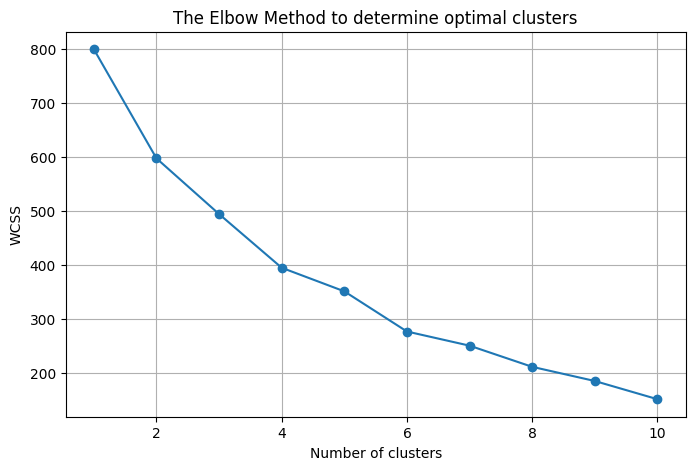

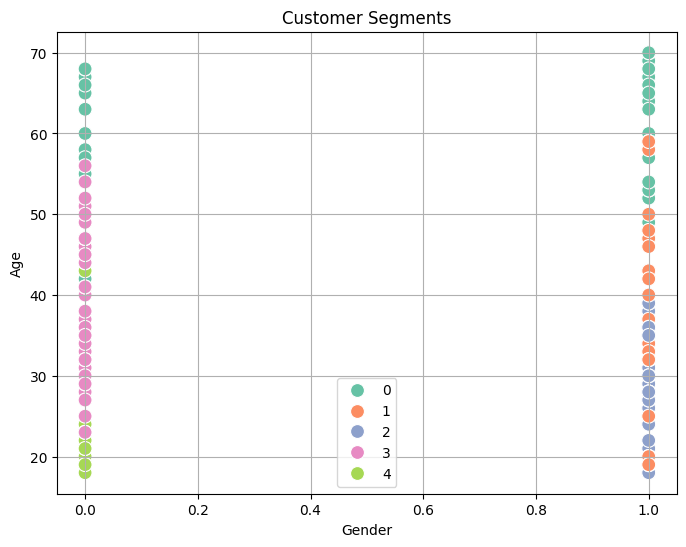

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.509804  56.470588           46.098039               39.313725
1        1.000000  39.500000           85.150000               14.050000
2        1.000000  28.690476           60.904762               70.238095
3        0.000000  37.897959           82.122449               54.448980
4        0.000000  27.315789           38.842105               56.210526


In [2]:
# 📌 STEP 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 📌 STEP 2: Load dataset
df = pd.read_csv("Dataset-csv.csv")

# Quick look at data
print(df.head())

# 📌 STEP 3: Drop CustomerID if it exists (replace with your actual ID column name)
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# 📌 STEP 4: Encode Gender if exists
if 'Gender' in df.columns:
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])

# 📌 STEP 5: Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 📌 STEP 6: Elbow Method to find optimal number of clusters
wcss = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, wcss, marker='o')
plt.title('The Elbow Method to determine optimal clusters')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# 📌 STEP 7: Choose optimal k based on the plot (e.g. 5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# 📌 STEP 8: Add cluster labels to original dataframe
df['Cluster'] = clusters

# 📌 STEP 9: Visualize clusters (choose two columns relevant to your dataset)
# Replace 'Annual Income (k$)' and 'Spending Score (1-100)' with your actual feature names if different
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df.columns[0],   # Use first numeric column or replace with your choice
    y=df.columns[1],   # Use second numeric column or replace with your choice
    hue='Cluster',
    palette='Set2',
    data=df,
    s=100
)
plt.title('Customer Segments')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.legend()
plt.grid(True)
plt.show()

# 📌 STEP 10: Cluster summary statistics
print(df.groupby('Cluster').mean())
